# Run an initial LLOWFSC calibration assuming the DM flat command is applied and we are well aligned to the vortex mask. 

In [ ]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
from datetime import timezone 
from pathlib import Path
from IPython.display import clear_output

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, coro_utils
from lina import llowfsc, rt_utils, dm

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

data_path = Path(f'../data/{today}-llowfsc')
utils.make_dir(data_path)


Directory '../data/20260428-llowfsc' already exists.


INFO:purepyindi2.transports:Connected to localhost:7624


# Connect to the SHMIM streams.

In [6]:
reload(coro_utils)

cam_channel = 'camlo294'

xc, yc = (6000, 2820)
xc, yc = (7000, 1500)
ncam = 1024

xc, yc = (5290, 5570)
# ncam = 1024
ncam = 96

coro_utils.set_cam_roi(xc, yc, ncam, client0, cam_name=cam_channel, bin_mode=2, delay=0.5)
coro_utils.set_cam_exp_time(0.00005, client0, cam_name=cam_channel)
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

Set camlo294 ROI.
Set the camlo294 exposure time to 5.00e-05s
Set the camlo294 gain setting to 0.0
Set the camlo294 blacklevel to 2.0


# Starting mean value = 1700

In [13]:
coro_utils.set_cam_exp_time(0.0001/2, client0, cam_name=cam_channel)

Set the camlo294 exposure time to 5.00e-05s


In [4]:
coro_utils.set_cam_gain(0, client0, cam_name=cam_channel)

Set the camlo294 gain setting to 0.0


In [5]:
coro_utils.set_cam_blacklevel(2, client0, cam_name=cam_channel)

Set the camlo294 blacklevel to 2.0


In [6]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [7]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [ ]:
coro_utils.move_block_out(client0)

In [25]:
reload(coro_utils)
coro_utils.move_psf(-1, 0, client0)

In [21]:
reload(coro_utils)
coro_utils.move_psf(0, -1, client0)

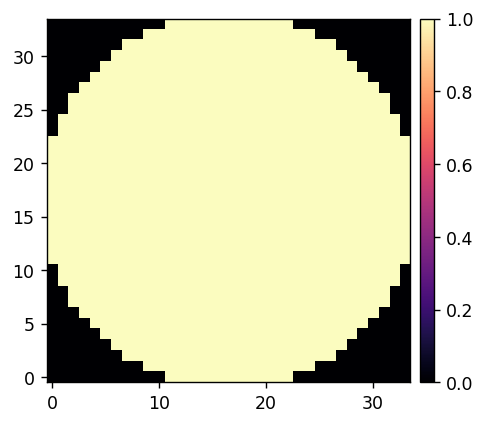

In [26]:
CAMLO_STREAM = ImageStream('camlo294')

DM_STREAMS = []
for i in range(1,11):
    DM_STREAMS.append(ImageStream(f'dm00disp{i:02}'))

rt_utils.create_shmim('llowfsc_zpo', (CAMLO_STREAM.shape[0], CAMLO_STREAM.shape[1]))
ZPO_STREAM = ImageStream('llowfsc_zpo')

rt_utils.create_shmim('llowfsc_gains', (10, 1))
GAINS_STREAM = ImageStream('llowfsc_gains')
rt_utils.write(GAINS_STREAM, np.array(2*[0.8] + 8*[0.05]))

Ncamlo = CAMLO_STREAM.shape[0]
Nact = DM_STREAMS[0].shape[0]

dm_mask = dm.create_mask(Nact=Nact, return_np=1)
utils.imshow(
    [dm_mask]
)

In [36]:
def take_im_fun(
        CAMLO_STREAM,
        NFRAMES=1,
    ):
    camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0)
    # camlo_im = np.mean(CAMLO_STREAM.grab_many(NFRAMES), axis=0) if NFRAMES>1 else CAMLO_STREAM.grab_after(1,0)[0]
    return camlo_im

take_im_params = {
    'CAMLO_STREAM':CAMLO_STREAM,
    'NFRAMES':1,
}

def set_dm_fun(
        command,
        DM_STREAM,
        wait_time=0.01,
    ):

    DM_STREAM.write(1e6*ensure_np_array(command))

set_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
    'wait_time':0.01,
}

def get_dm_fun(
        DM_STREAM,
    ):

    return 1e-6*DM_STREAM.grab_latest()


get_dm_params = {
    'DM_STREAM':ImageStream('dm00disp01'),
}

def get_gains():
    return GAINS_STREAM.grab_latest()[0]

def get_zpo(ZPO_STREAM):
    return ZPO_STREAM.grab_latest()

get_zpo_params = {
    'ZPO_STREAM':ZPO_STREAM,
}

# Obtain a reference dark image for the camera settings that will be used during the duration of LLOWFSC.

In [28]:
coro_utils.move_block_in(client0)

INFO:utils:Got semaphore index 1.


Saved data to:  ../data/20260428-llowfsc/camlo_dark_0.000050s_0gain.fits


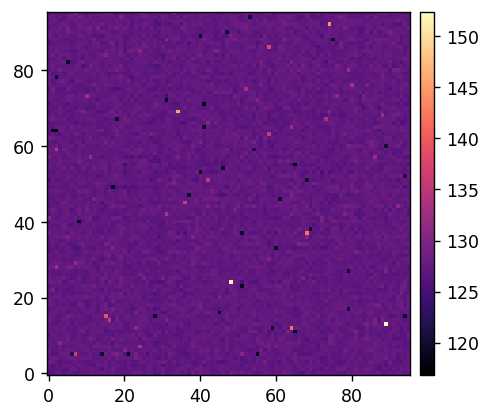

In [29]:

take_im_params.update({
    'NFRAMES':200,
})

camlo_dark = take_im_fun(**take_im_params)

exp_time = coro_utils.get_cam_exp_time(client0, cam_channel)
gain = coro_utils.get_cam_gain(client0, cam_channel)
utils.save_fits(data_path/f'camlo_dark_{exp_time:.6f}s_{gain:.0f}gain.fits', camlo_dark)

utils.imshow([camlo_dark])

In [30]:
coro_utils.move_block_out(client0)

# Obtain the reference image.

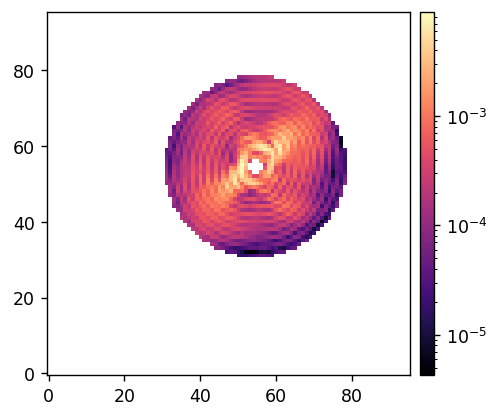

In [51]:
reload(llowfsc)

irad = 2
orad = 24
wfs_mask = utils.create_annular_focal_plane_mask(
    CAMLO_STREAM.shape[0], 
    1, 
    irad, 
    orad, 
    edge=None, 
    x_shift=7,
    y_shift=7,
    centering='even', 
    return_np=1,
)

take_im_params.update({
    'NFRAMES':400,
})

ref_im, flux_norm_coeff = llowfsc.acquire_ref(
    take_im_fun,
    take_im_params,
    wfs_mask,
    camlo_dark=camlo_dark,
    flux_norm=True,
)

utils.imshow(
    [ref_im],
    norms=[LogNorm()] 
)


# Calibrate for the set of Zernike modes that we want to control.

Calibrated mode 1/10 in 0.691s

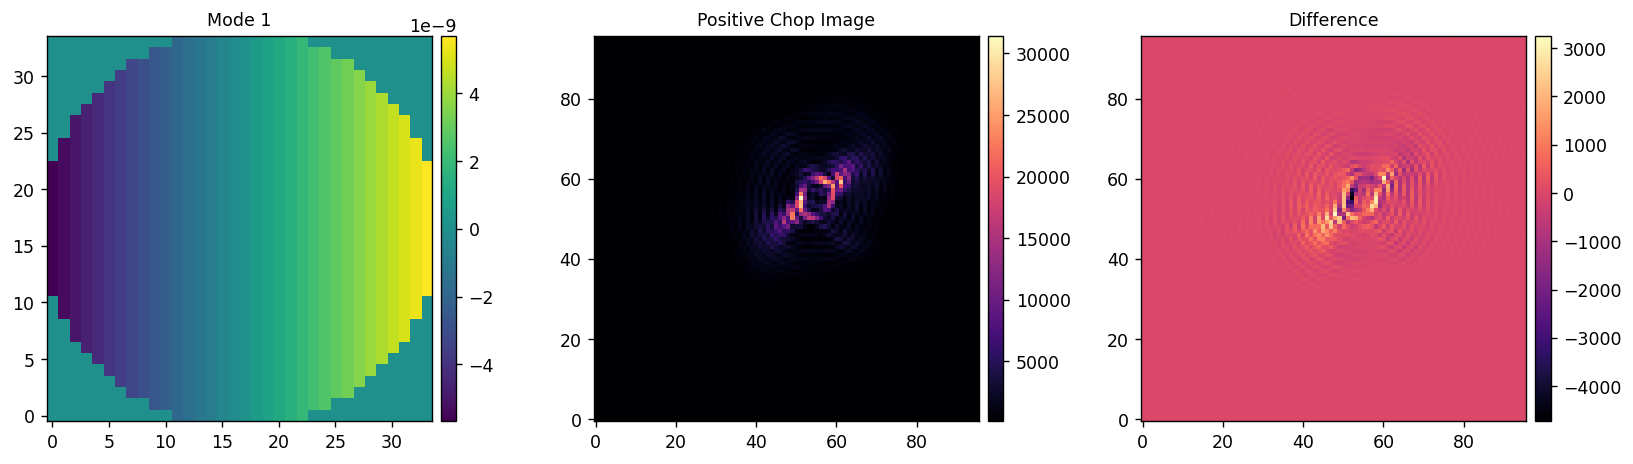

Calibrated mode 2/10 in 1.847s

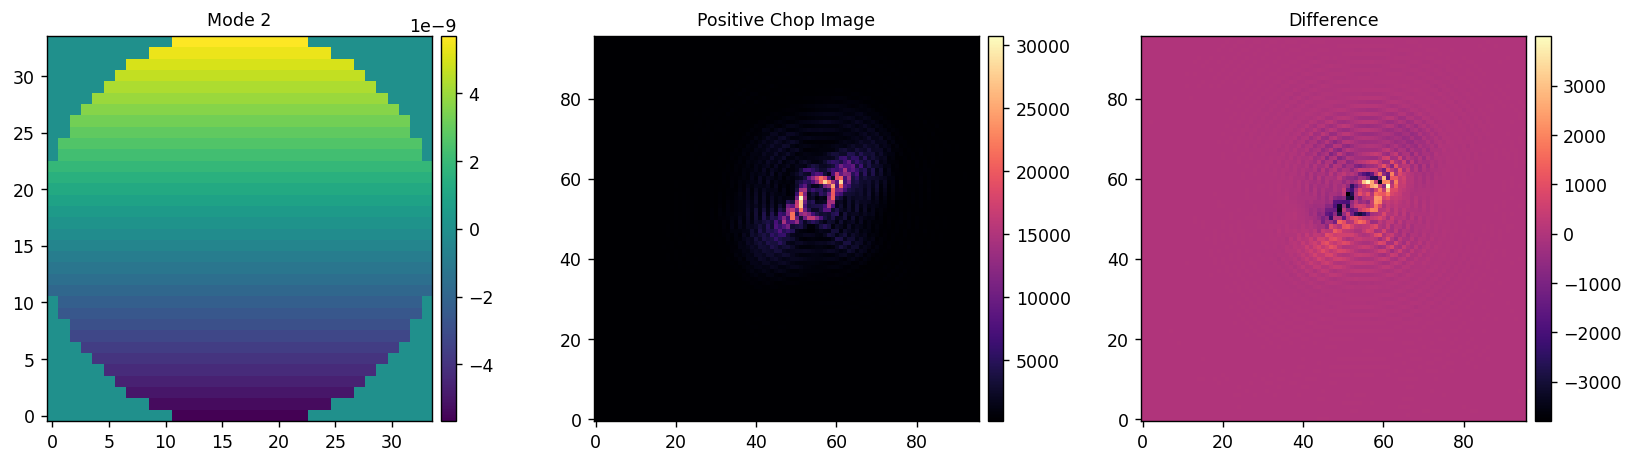

Calibrated mode 3/10 in 3.048s

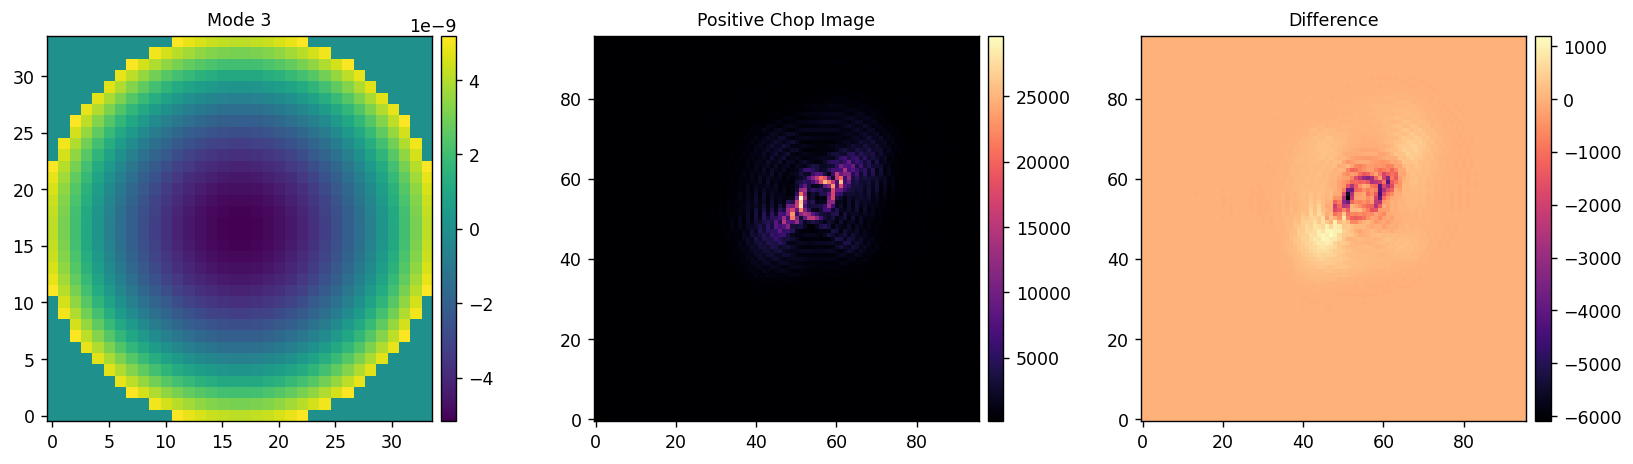

Calibrated mode 4/10 in 4.183s

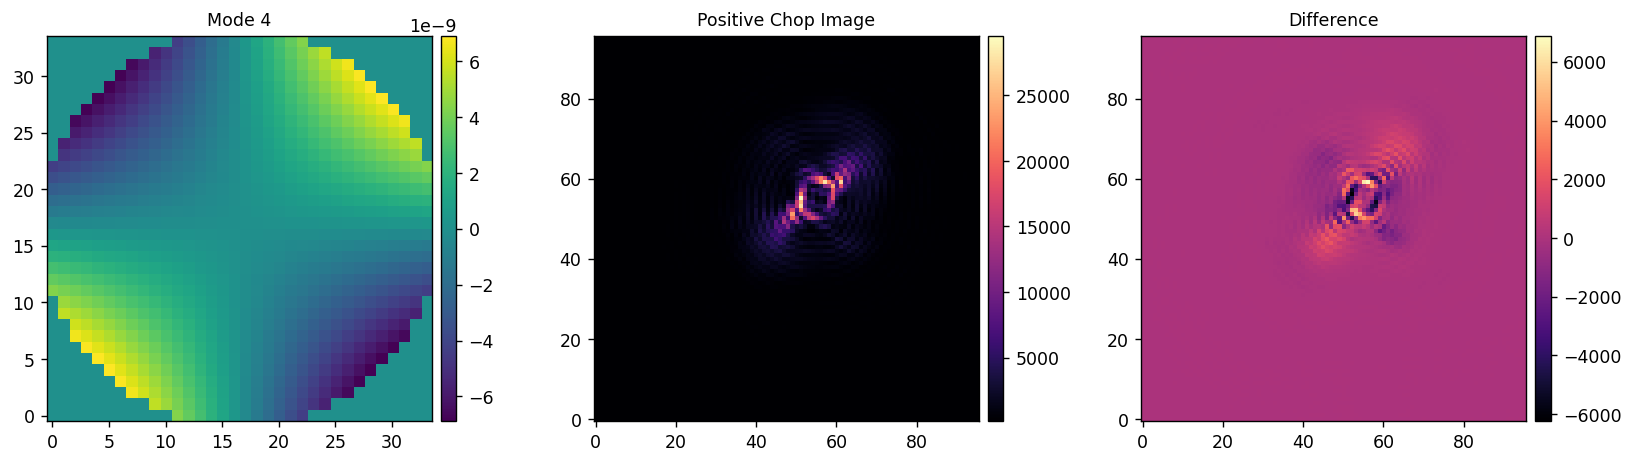

Calibrated mode 5/10 in 5.342s

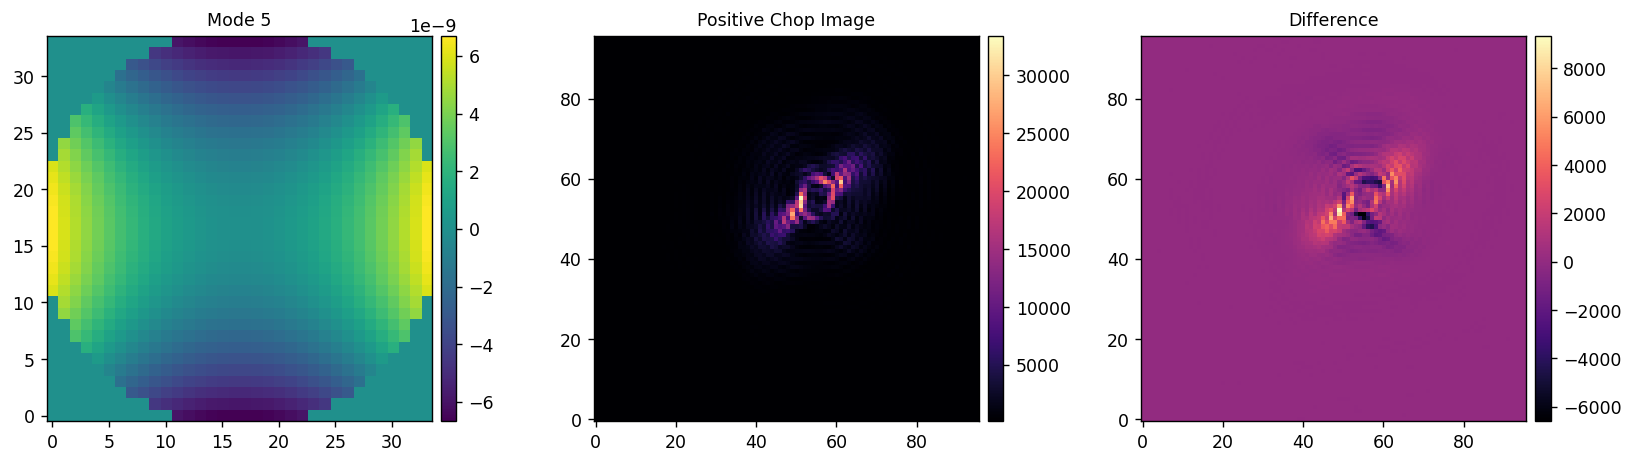

Calibrated mode 6/10 in 6.653s

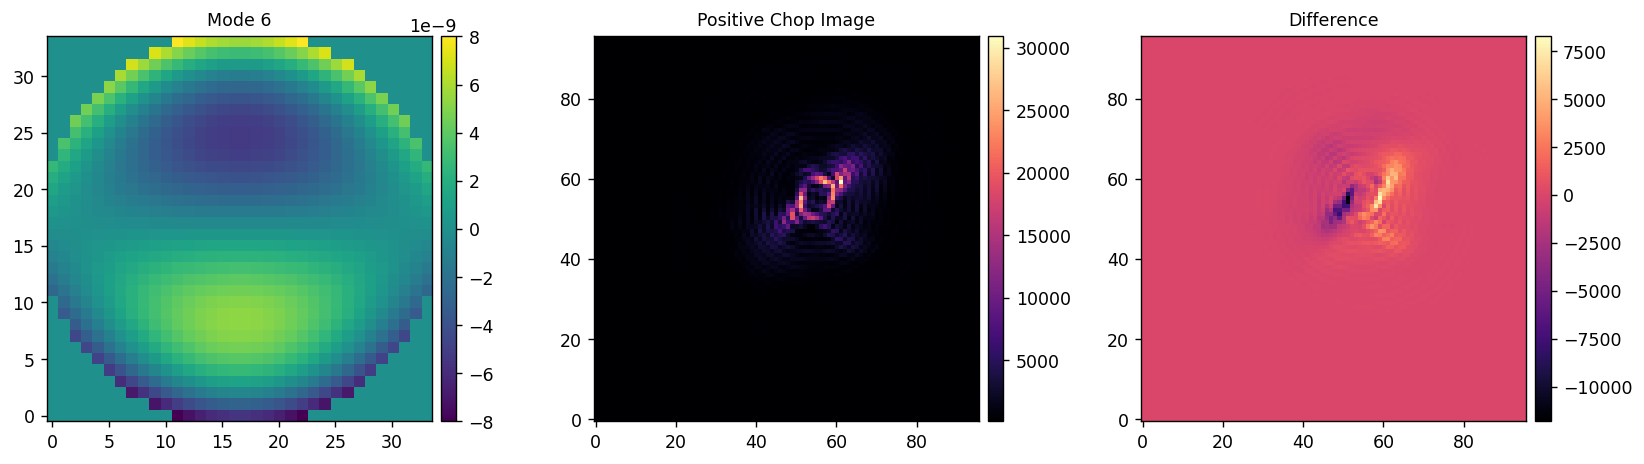

Calibrated mode 7/10 in 7.802s

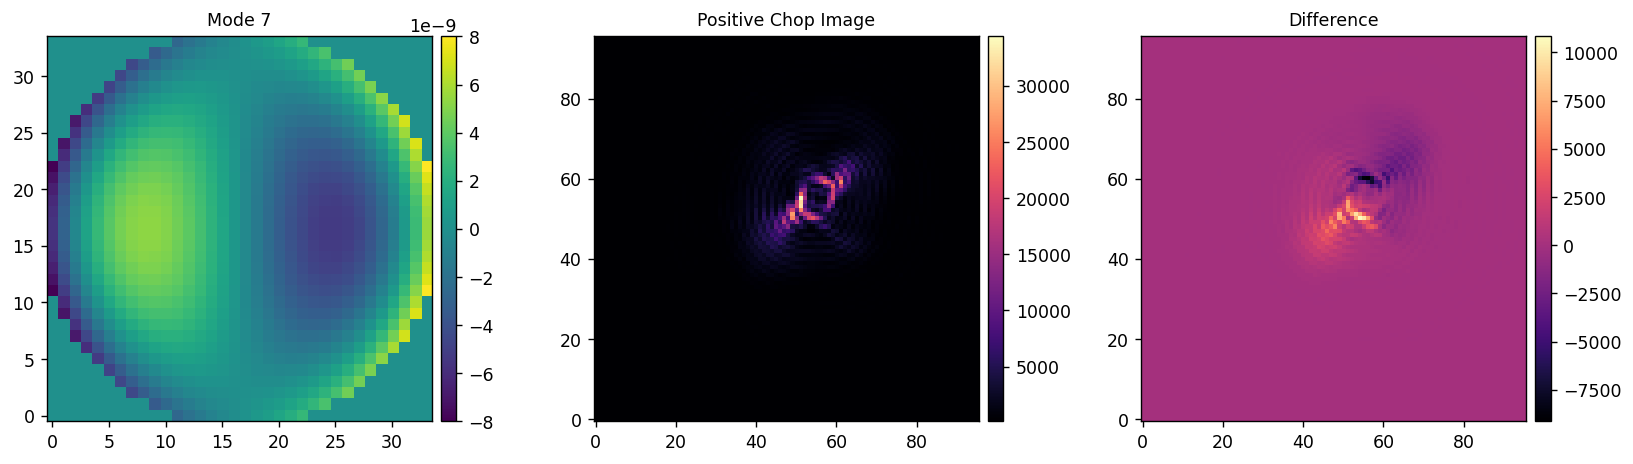

Calibrated mode 8/10 in 9.031s

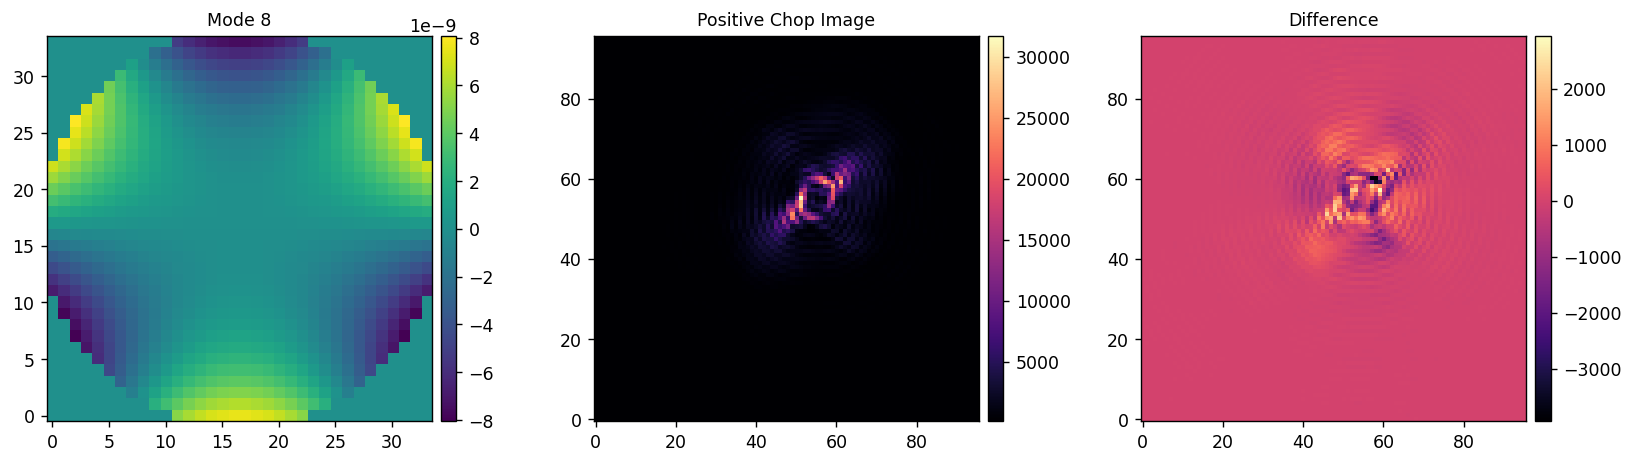

Calibrated mode 9/10 in 10.183s

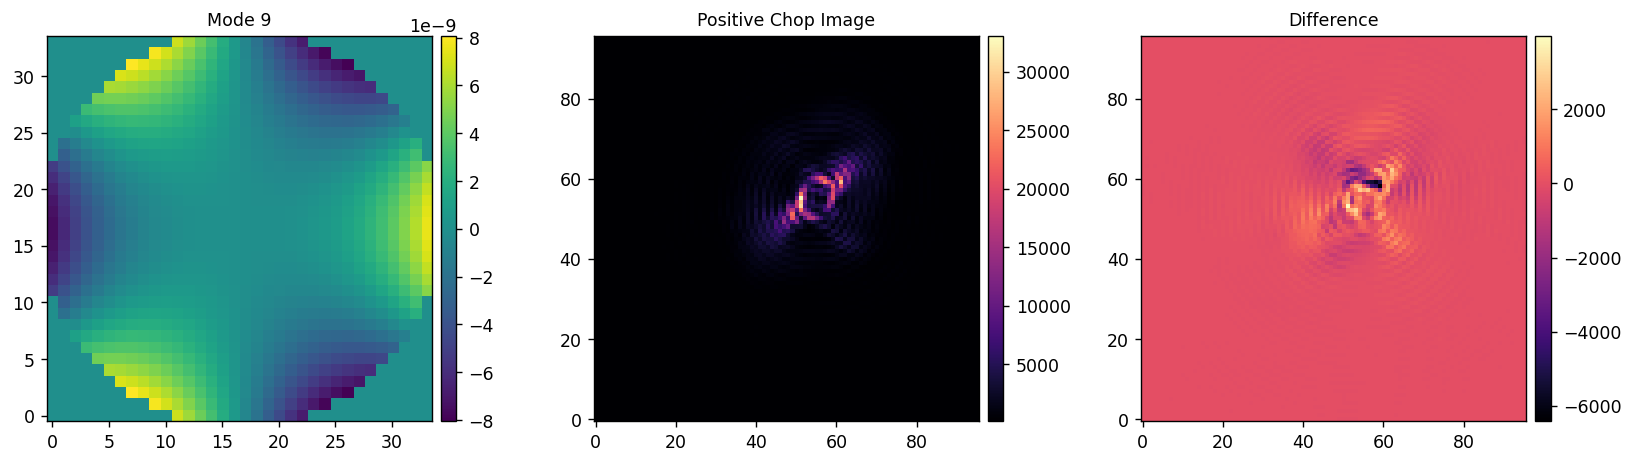

Calibrated mode 10/10 in 11.305s

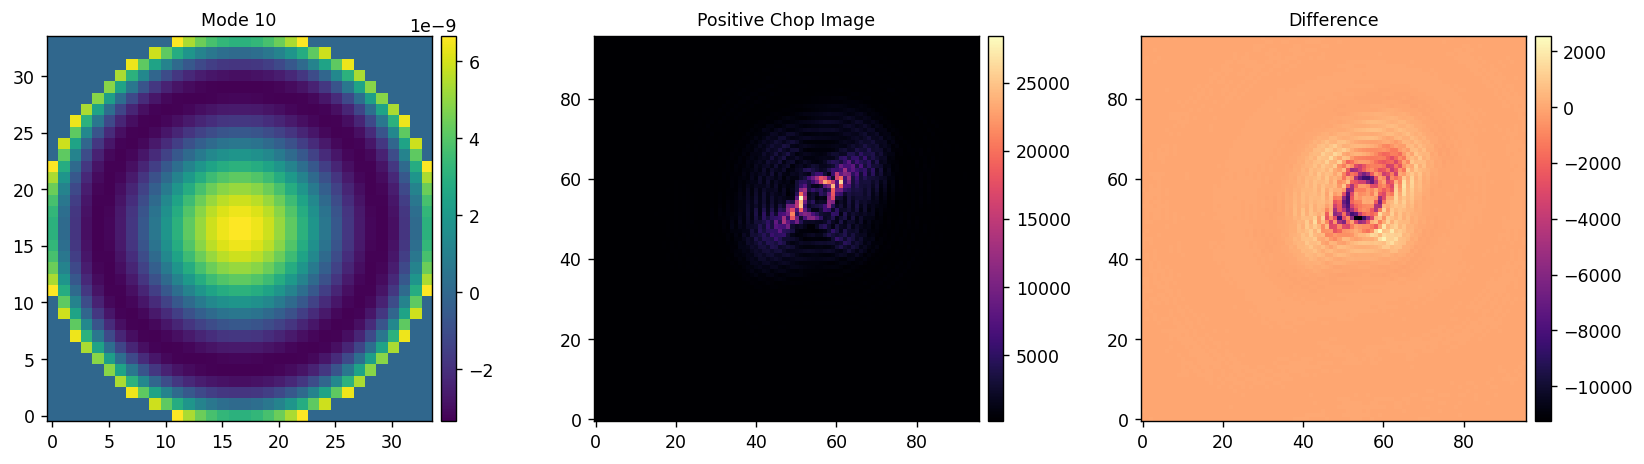

In [52]:
reload(llowfsc)
reload(dm)
reload(utils)

Nmodes = 10

dm_zer_mask = utils.pad_or_crop(dm.create_mask(Nact=Nact, return_np=1), DM_STREAMS[0].shape[0])
dm_zernike_modes = dm.create_zernike_modes(dm_zer_mask, nmodes=Nmodes, remove_modes=1, return_np=1)
# utils.imshow([dm_zernike_modes[0], dm_zernike_modes[3], dm_zernike_modes[-1]], cmaps=3*['viridis'])

take_im_params.update({
    'NFRAMES':100,
})

zer_rm, zer_response_cube = llowfsc.calibrate_dm_modes(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    dm_zernike_modes, 
    wfs_mask, 
    amp=3e-9, 
    flux_norm_coeff=flux_norm_coeff,
    # include_factor_2=True, 
    plot=True,
)


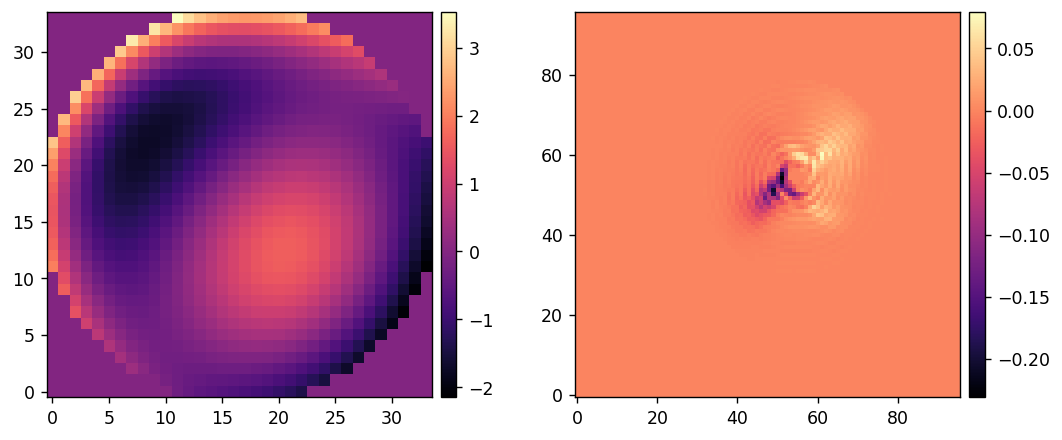

In [53]:
reload(utils)
P, U, s, Vt = utils.tikhonov_inverse(zer_rm, 0, return_all=1, return_np=1)

dm_modes = np.zeros((Nmodes, Nact, Nact))
wfs_modes = np.zeros((Nmodes, Ncamlo, Ncamlo))
for i in range(Nmodes):
    dm_modes[i, dm_mask] = Vt.dot(dm_zernike_modes[:, dm_mask])[i]
    # dm_modes[i, dm_mask] = Vt.T.dot(dm_zernike_modes[:, dm_mask])[i]
    wfs_modes[i, wfs_mask] = U.T[i] 

# dm_modes = Vt.dot(dm_zernike_modes[:, dm_mask])
# wfs_modes = U.T

# dm_modes.shape

i = 0
utils.imshow(
    [dm_modes[i], wfs_modes[i]]
)

# Reconstruct the Zernike modes applied to the DM to understand the linearity and coupling of LLOWFSC. 

In [54]:
znames = [
    'Tip', 'Tilt', 
    'Defocus', 'O-Astig', 'V-Astig', 
    'V-Coma', 'H-Coma', 'V-Trefoil', 'O-Trefoil', 'Spherical', 
    # 'V-Astig 2', 'O-Astig 2', 'V-Quadrafoil', 'O-Quadrafoil', 'H-Coma 2', 'V-Coma 2', 'O-Trefoil 2', 'V-Trefoil 2', 
    # 'O-Pentafoil 2', 'V-Pentafoil',
]
len(znames)

10

In [64]:
coro_utils.set_fiber_atten(0, client)

Set the fiber attenuation to 0.0


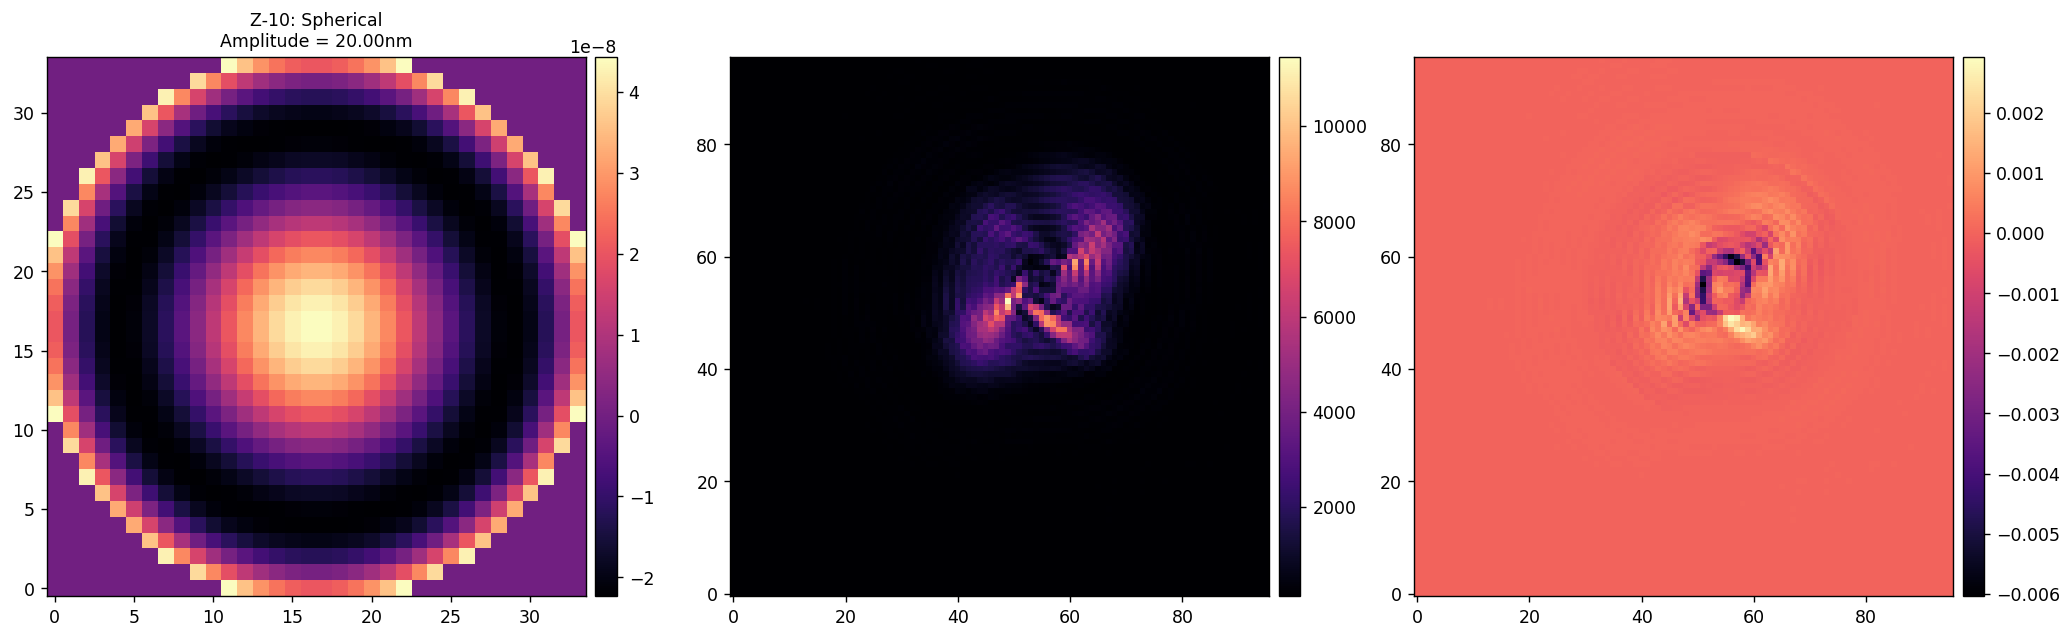

[ 1.13191987e-09 -3.80211089e-09  1.40107624e-08 -5.65090210e-10
  1.05338687e-11  3.06420692e-09  1.52112049e-09  1.50795199e-09
  2.93216305e-10  4.16189426e-09]


In [59]:
reload(llowfsc)

take_im_params.update({
    'NFRAMES':100,
})

Nz_modes = len(znames)

Namps = 41
Namps = 21
wfe_amps = np.linspace(-20e-9, 20e-9, Namps)

coeff = np.zeros((Nz_modes, Namps, Nz_modes))
for i in range(Nz_modes):
    for j in range(Namps):
        amp = wfe_amps[j]
        # M.PREFPM_OPD = wfe_data['PREFPM_OPD'] + amp * wfe_modes[i]
        # M.set_actor_attr('PREFPM_OPD', wfe_data['PREFPM_OPD'] + amp*wfe_modes[i])
        # M.set_prefpm_wfe(PREFPM_OPD0 + amp * wfe_modes[i])
        # camlo_im = M.snap_camlo()

        set_dm_fun(amp * dm_zernike_modes[i], **set_dm_params)
        camlo_im = take_im_fun(**take_im_params)

        modal_coeff, del_im = llowfsc.reconstruct(
            camlo_im, 
            ref_im, 
            wfs_mask,
            P,
            dark_im=camlo_dark,
            # which_modes='tt',
            modes=(0,10),
            flux_norm=True,
            return_del_im=True,
        )
        
        coeff[i,j,:] = copy.copy(modal_coeff)
        
        if j%2==0:
            utils.imshow(
                [amp*dm_zernike_modes[i], camlo_im, del_im], 
                titles=[f'Z-{i+1:d}: '+ znames[i] + f'\nAmplitude = {amp*1e9:.2f}nm'],
                figsize=(20,8),
            )
            print(modal_coeff)
            clear_output(wait=True)
    
set_dm_fun(xp.zeros_like(dm_mask), **set_dm_params)

# Plot the linearity and coupling data. 

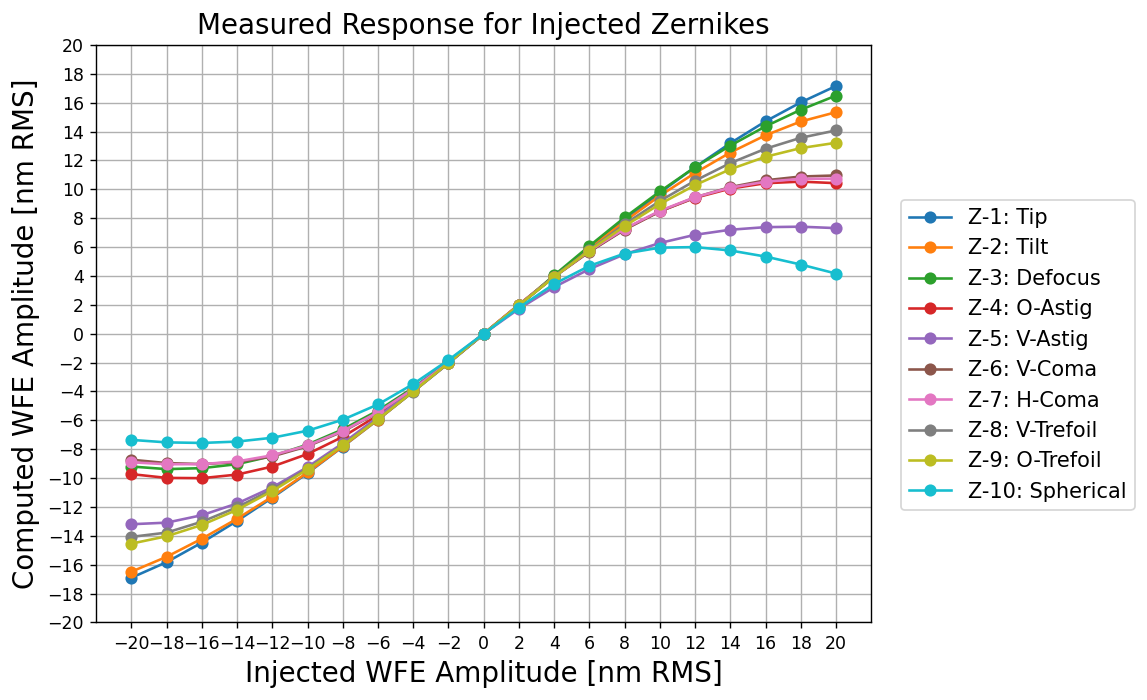

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(8,6), dpi=125)

for i in range(Nz_modes):
    label = f'Z-{i+1:d}: ' + znames[i]
    style = '-o' if i<10 else '-x'
    ax.plot(wfe_amps*1e9, 1e9*ensure_np_array(coeff[i,:,i]), style, label=label)
ax.set_title('Measured Response for Injected Zernikes', fontsize=16)
ax.set_xlabel('Injected WFE Amplitude [nm RMS]', fontsize=16)
ax.set_ylabel('Computed WFE Amplitude [nm RMS]', fontsize=16)
ax.legend(bbox_to_anchor=[1.025, 0.75], fontsize=12)
ax.set_xticks(wfe_amps[::1]*1e9)
ax.set_yticks(wfe_amps[::1]*1e9)
ax.grid()

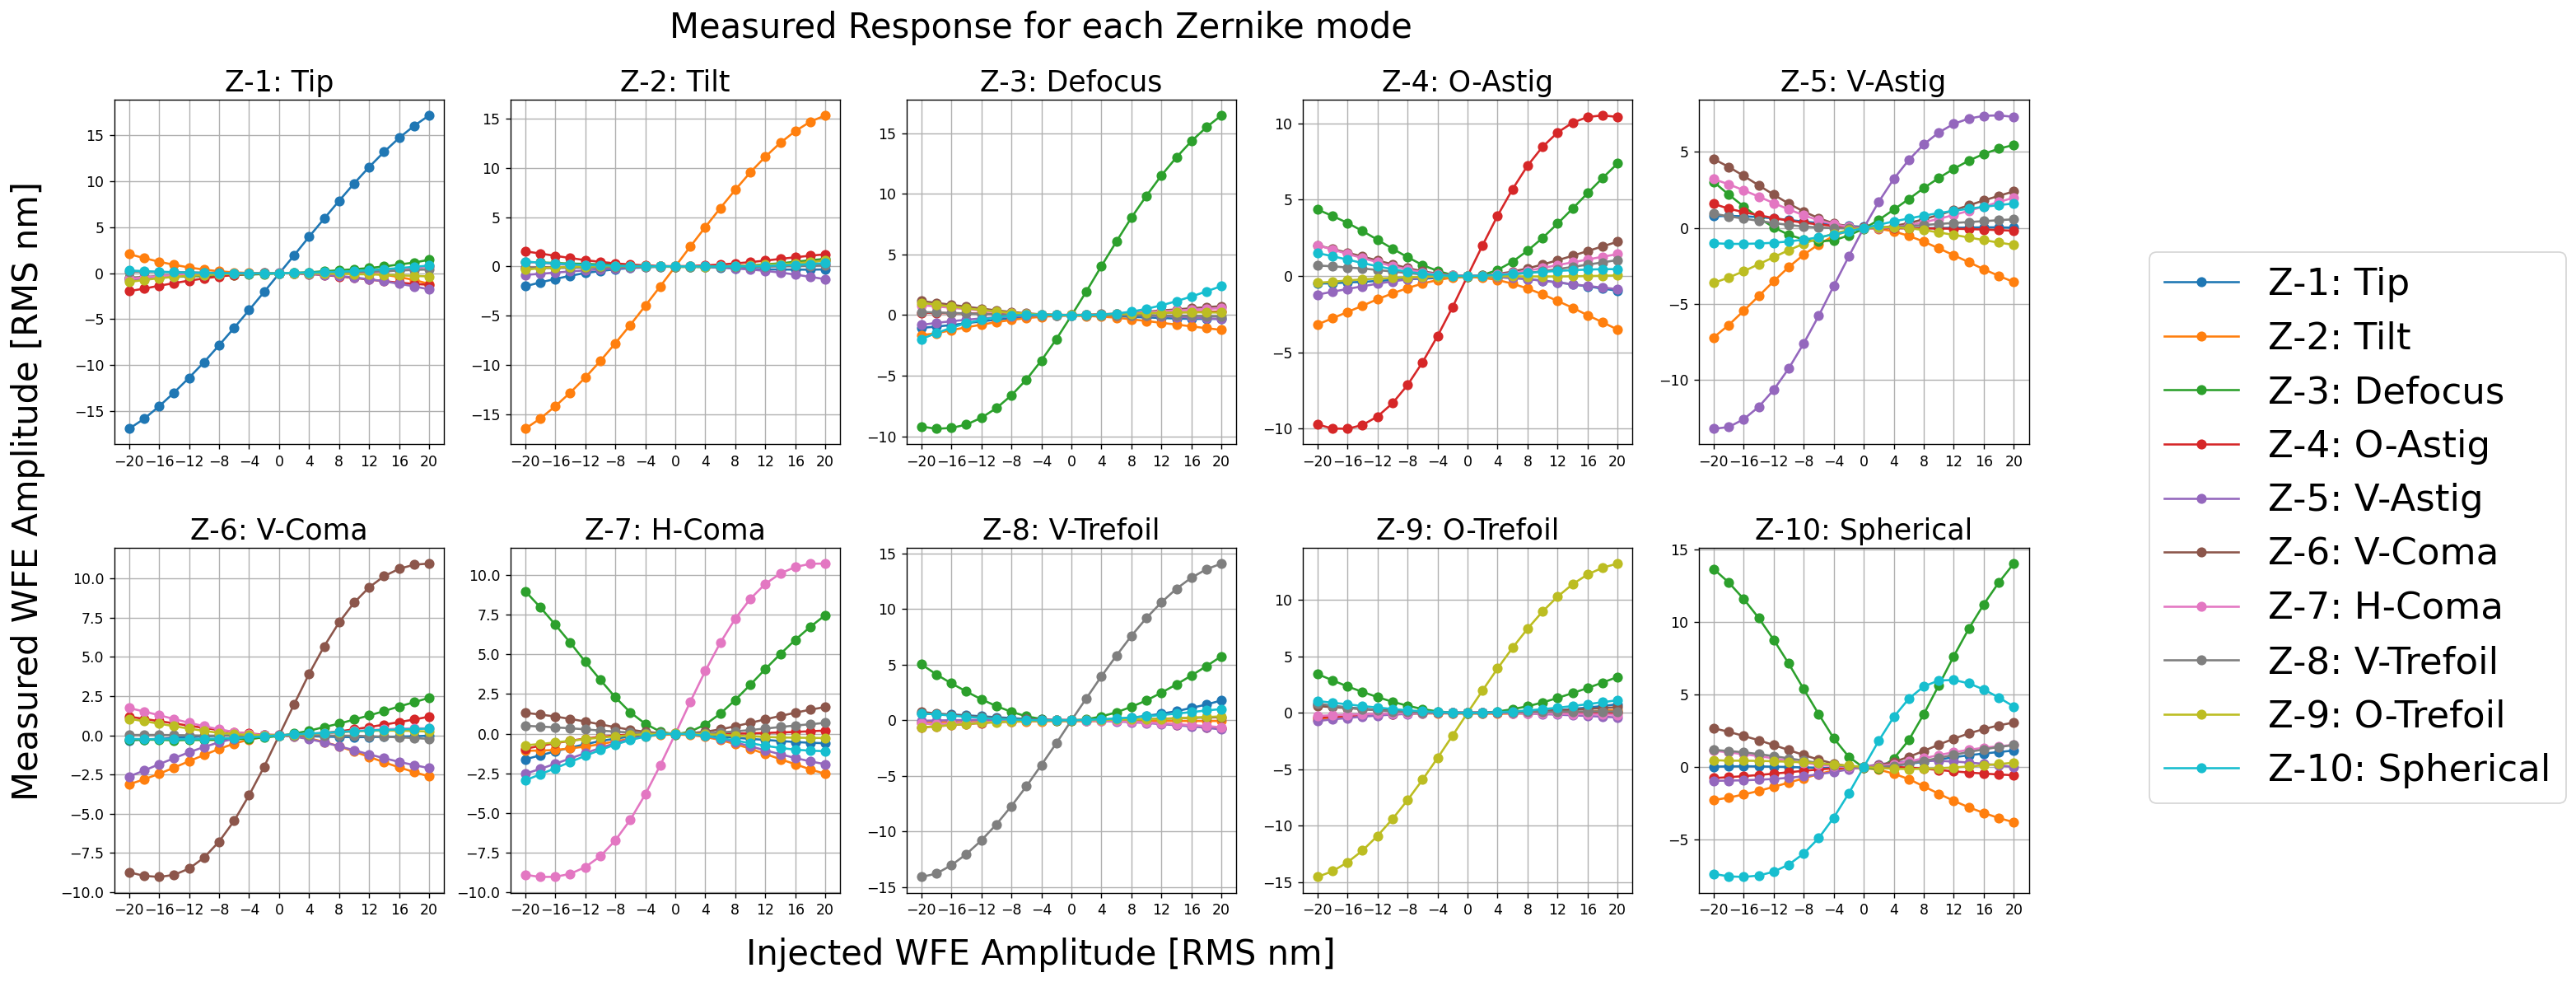

In [63]:

fig, ax = plt.subplots(2,5, figsize=(24,10), dpi=125)

for i in range(Nz_modes):
    ax_ind = [int(np.floor(i/5)), i%5]
    for j in range(Nz_modes):
        label = f'Z-{j+1:d}: '+znames[j]
        style = '-o' if j<10 else '-x'
        ax[ax_ind[0], ax_ind[1]].plot(wfe_amps*1e9, 1e9*ensure_np_array(coeff[i,:,j]), style, label=label)
    ax[ax_ind[0], ax_ind[1]].set_title(f'Z-{i+1:d}: '+znames[i], fontsize=20)
    ax[ax_ind[0], ax_ind[1]].set_xticks(wfe_amps[::2]*1e9)
    ax[ax_ind[0], ax_ind[1]].grid()
# ax.legend(bbox_to_anchor=[1.2, 1.1])
fig.text(0.5, 0.05, 'Injected WFE Amplitude [RMS nm]', fontsize=24, ha='center', va='center')
fig.text(0.09, 0.5, 'Measured WFE Amplitude [RMS nm]', ha='center', va='center', fontsize=24, rotation='vertical')
fig.text(0.5, 0.95, 'Measured Response for each Zernike mode', fontsize=24, ha='center', va='center')
handles, labels = ax[-1,-1].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=[1.125, 0.75], fontsize=26)
plt.subplots_adjust(hspace=0.3)